##### Importing the modules required 

In [1]:
import os
import numpy as np
from scipy.stats import median_abs_deviation
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

#### Pyfli modules
from pyfli import DataOperations, IRFAligner, PhasorAnalyzer, DataPreprocessing, DataViewer
from pyfli import AnalyticalHelpers, Colorprocess, DataIO_utils, Normalization, DataSaver
from pyfli import MLEFLIFitter, BaseFLIFitter, BinnedFliFitter, FliBinner 
from pyfli import Fli_CPUProcessor, Fli_GPUProcessor
from pyfli import ROIMaker
from pyfli import random_true_pixel
from pyfli import Plotter


In [ ]:
# making the zero values to black
jet_m = Colorprocess().lowest_zero('jet')
saver_active = [False, True][1]
free_memory = [False, True][1]  # set True to release intermediate arrays after each stage

In [4]:
# Align folder/file paths for analysis 
data_path = "../data/microscopy/nanobody/Exp 41_HCC1954_DL2_1 h_image 3.sdt"
irf_path = '../data/microscopy/nanobody/Average IRF 2022-10-27 (for SPCImage, 256).txt'
roiN_mask_path = '../data/microscopy/nanobody/Exp 41_HCC1954_DL2_1 h_image 3 Multiple ROIs.roiN'

In [5]:
loader = DataOperations(    
    data_path= data_path,
    irf_path= irf_path, 
    bg_path = None,   
    mask_path= None
    )

In [6]:
# Intitalizating for data saver to start saving data,
new_session = [False, True][1] 
if saver_active:
    print('Saver is called for keeping the log of this session')
    saver = DataSaver(path=data_path, folder_name="_pyfli_Analysis_Results", new_session= new_session)
    print(f'>>>>> Saving Folder >>>>>>>>>>>>>>>>>> \n"{saver.save_dir}"')

In [7]:
##### Data loading
decay_raw = loader.load_data()
irf_raw = loader.load_irf()
print(f'decay shape is : {decay_raw.shape}')
print(f'IRF shape is: {irf_raw.shape}')
map_array = np.ones((decay_raw.shape[0], decay_raw.shape[1]), dtype=bool)
roiN_mask = DataIO_utils().roiNloader(map_array=map_array, file_path = roiN_mask_path)
print(f'roiN mask made from Alligator: {roiN_mask.shape}')

Initiating DATA load from: ../data/microscopy/nanobody/Exp 41_HCC1954_DL2_1 h_image 3.sdt
Initiating IRF load from: ../data/microscopy/nanobody/Average IRF 2022-10-27 (for SPCImage, 256).txt
decay shape is : (512, 512, 256)
IRF shape is: (512, 512, 256)
roiN mask made from Alligator: (512, 512)


In [8]:
save_this = False
if save_this:
    saver.save_npy('decay', decay_raw)
    saver.save_npy('irf', irf_raw)
    saver.save_npy('mask', roiN_mask)

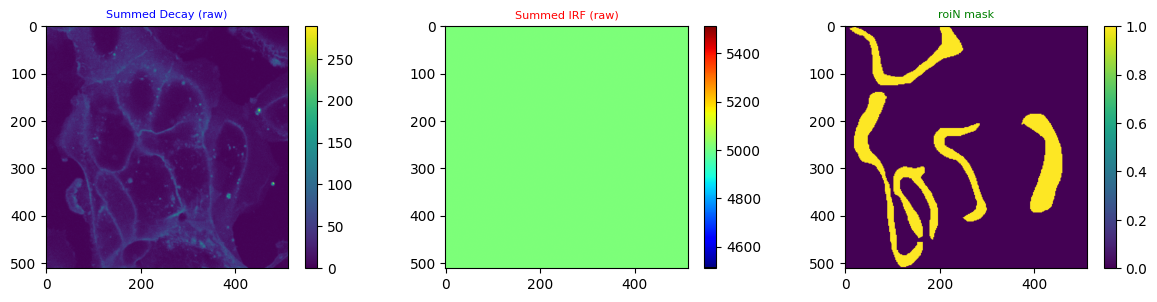

In [9]:
#### data visualization and saving
fig, axes = plt.subplots(1,3, figsize=(12,3))
im0 = axes[0].imshow(np.sum(decay_raw, axis=2), cmap = 'viridis')
fig.colorbar(im0, ax = axes[0])
axes[0].set_title('Summed Decay (raw)', fontsize = 8, color = 'blue')
im1 = axes[1].imshow(np.sum(irf_raw, axis=2), cmap = jet_m)
fig.colorbar(im1, ax = axes[1])
axes[1].set_title('Summed IRF (raw)', fontsize = 8, color = 'red')
im2 = axes[2].imshow(roiN_mask, cmap = 'viridis')
fig.colorbar(im2, ax = axes[2])
axes[2].set_title('roiN mask', fontsize = 8, color = 'green')
plt.tight_layout()
plt.show()

In [10]:
save_this = False
if save_this:
    saver.save_plot(name='raw_data', fig=fig)

In [11]:
intensity_threshold_min = 30
intensity_threshold_max = 200
bin_r = 2

In [12]:
save_this = False
if save_this:
    saver.save_params(Intensity_threshold_min= intensity_threshold_min, 
                      Intensity_threshold_max = intensity_threshold_max,
                      Binning_applied = bin_r
                      )

In [13]:
mul_factor = (2*bin_r+1)*(2*bin_r+1)
print(f'the multiplication factor in comparison to unbinned is: {mul_factor}')
binner = FliBinner(bin_radius=bin_r)
b_decay, b_irf = binner.apply_binning(decay_raw, irf_raw)
if free_memory:
    del decay_raw, irf_raw

the multiplication factor in comparison to unbinned is: 25
Applying spatial binning: Radius=2 (5x5 window)


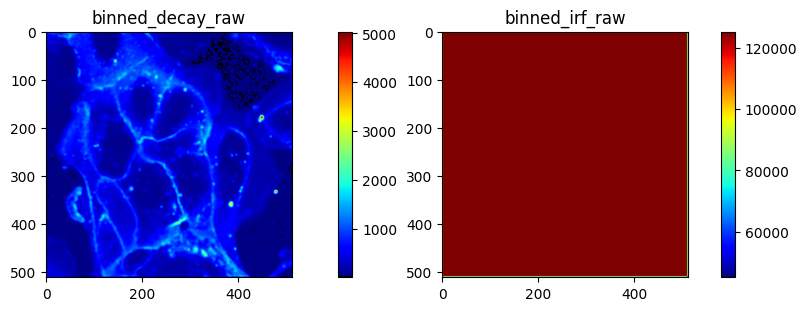

In [14]:
###### bin has been applied --- >  the scale will change
data_list1 = [b_decay, b_irf]
data_names1 = ['binned_decay_raw', 'binned_irf_raw']
cmaps = [jet_m, 'jet']

px = None
save_this = False
if save_this:
    DataViewer(save_path=saver.save_dir, fig_name='binned_data').display_data(data_list1, structure=(1, 2), coord=px, data_names=data_names1, 
                     cmaps=cmaps, v_ranges=None, figsize=(8,3), normalize=False, yscale = 'linear')
else:
    DataViewer().display_data(data_list1, structure=(1, 2), coord=px, data_names=data_names1, 
                     cmaps=cmaps, v_ranges=None, figsize=(8,3), normalize=False, yscale = 'linear')

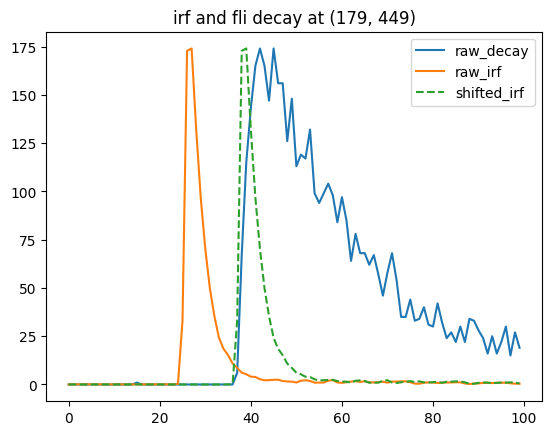

In [15]:
b_irf_corr = IRFAligner(b_decay, b_irf)
b_irf_shifted, _ = b_irf_corr.align(fraction=0.05, method='circular', manual_correction=0.4)
decay_intensity = np.sum(b_decay, axis=2)
x_px, y_px = np.unravel_index(np.argmax(decay_intensity), decay_intensity.shape)

# Checking the graph to '_till" point for rising-edge matching
# save_this = True

_till = 100 
plt.plot(b_decay[x_px, y_px,:_till], label = 'raw_decay')
plt.plot(Normalization(b_irf[x_px, y_px,:_till]).norm_scale(b_decay[x_px, y_px,:_till]), label='raw_irf')
plt.plot(Normalization(b_irf_shifted[x_px, y_px,:_till]).norm_scale(b_decay[x_px, y_px,:_till]), '--', 
         label='shifted_irf')
plt.title(f'irf and fli decay at ({x_px}, {y_px})')
plt.legend()

if save_this:
    saver.save_plot(name='shift_correction', fig=None, close=False)
plt.show()
if free_memory:
    del b_irf

##### Spatial Invariant IRF

In [16]:
# making universal IRF (only for microscopy workflow assuming the IRF spatial invariant)
irf_pixel_1d = b_irf_shifted[x_px, y_px, :]
if free_memory:
    del b_irf_shifted
b_m_irf = np.tile(irf_pixel_1d, (512, 512, 1))
print(b_m_irf.shape)
# save_this = True
if save_this:
    saver.save_npy('pixel_invariant_irf', irf_pixel_1d)  # 1D vector only — same info, far smaller on disk

(512, 512, 256)


##### process with Binary Mask

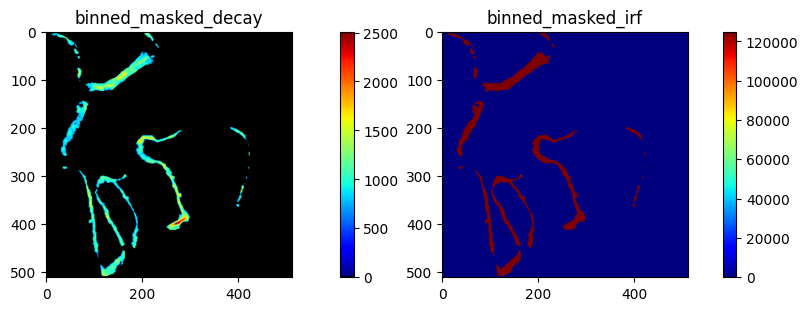

In [17]:
from pyfli import data_masking
thrs = ['combined', 'separate'][0] ## if handdrawn and intensity threshold applied together or seperate

if thrs == 'separate':
    if roiN_mask.all() != 1:
        b_bool_mask = roiN_mask
        b_fli_masked, b_irf_masked = data_masking(b_decay, b_m_irf, mask = b_bool_mask)
    else:
        binned_datac = DataPreprocessing(b_decay, b_m_irf)
        b_bool_mask = binned_datac.threshold_masking(lower= intensity_threshold_min*mul_factor, upper= intensity_threshold_max*mul_factor)
        b_fli_masked, b_irf_masked = binned_datac.apply_mask(mask = b_bool_mask)
else:
    b1_bool_mask = roiN_mask
    roiN_b_fli_masked, roiN_b_irf_masked = data_masking(b_decay, b_m_irf, mask = b1_bool_mask)
    roiN_binned_datac = DataPreprocessing(roiN_b_fli_masked, roiN_b_irf_masked)
    b_bool_mask = roiN_binned_datac.threshold_masking(lower= intensity_threshold_min*mul_factor, upper= intensity_threshold_max*mul_factor)
    b_fli_masked, b_irf_masked = roiN_binned_datac.apply_mask(mask = b_bool_mask)


data_list2 = [b_fli_masked, b_irf_masked ]
data_names2 = ['binned_masked_decay', 'binned_masked_irf']
cmaps = [jet_m, 'jet']
px = None
# save_this = True
if save_this:
    DataViewer(save_path=saver.save_dir, fig_name='binned_masked').display_data(data_list2, structure=(1, 3), coord=px, data_names=data_names2, 
                     cmaps=cmaps, v_ranges=None, figsize=(12,3), normalize=False, yscale = 'linear')
else:
    DataViewer().display_data(data_list2, structure=(1, 3), coord=px, data_names=data_names2, 
                     cmaps=cmaps, v_ranges=None, figsize=(12,3), normalize=False, yscale = 'linear')

In [18]:
# Finalized the name for further data processing
binned_decay, binned_irf = b_fli_masked, b_irf_masked
if free_memory:
    del b_decay, b_m_irf, b_fli_masked, b_irf_masked
    try:
        del roiN_b_fli_masked, roiN_b_irf_masked
    except NameError:
        pass

In [19]:
# save_this = True
if save_this:
    saver.save_npy('clean_decay', binned_decay)
    saver.log('The clean decay saved')
    saver.save_npy('clean_irf', binned_irf)
    saver.log('The clean irf saved')
    saver.save_npy('final_mask', b_bool_mask)
    saver.log('final bool mask saved')

In [20]:
# save_this = True
# Set-up (Camera Acquisition) parameters
gate_delay = 12.5/binned_irf.shape[2]
num_gates = binned_irf.shape[2]
freq = AnalyticalHelpers(laser_period = 12.5, gate_delay=gate_delay, num_gate = num_gates).freq_computation() 
print(f'the effective frequency is {freq[1]} MHz')
freq_hz = freq[1] * 1e6
time_axis_ns = np.linspace(0, gate_delay*num_gates, binned_irf.shape[2])
if save_this:
    saver.log('-'*40)
    saver.log('The time-resolved imaging parameters are:')
    saver.save_params(Gate_delay = gate_delay, 
                    Number_of_gates_or_bins = num_gates, 
                    Frequency = freq)
    saver.log('-'*40)

the effective frequency is 80.0 MHz


In [21]:
##### Select a color of choice for phasor
# colorset = ['winter', 'managua', 'grey', 'magma', 'summer', 'pink' ][-1]  # default is autumn
# colorset = ['viridis', 'plasma', 'inferno', 'magma', 'cividis'][1]
colorset = [ 'ocean', 'gist_earth', 'terrain',
                      'gist_stern', 'gnuplot', 'gnuplot2', 'CMRmap',
                      'cubehelix', 'brg', 'gist_rainbow', 'rainbow', 'jet', 'jet_r',
                      'turbo', 'nipy_spectral', 'gist_ncar'][-6]

# colorset = ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu',
#                       'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic',
#                       'berlin', 'managua', 'vanimo'][-1]
if save_this:
    saver.save_params(Phasor_color = colorset)

In [22]:
Phasor_binned = PhasorAnalyzer(frequency_hz=freq_hz, time_axis_ns=time_axis_ns, n_harmonics=3)
# Phasor computation (3-HARMONICS computed here)
binned_G, binned_S = Phasor_binned.create_phasor_gpu(binned_decay)
binned_Gc, binned_Sc = Phasor_binned.calibrate_pixelwise(binned_G, binned_S, binned_irf) # pixelwise-IRF calibration
binned_tau_map_ns = Phasor_binned.compute_lifetime(binned_Sc[0], binned_Gc[0])

In [23]:
Phasor_binned.save_phasors_hdf5(binned_Gc, 
                                binned_Sc, 
                                binned_tau_map_ns, 
                                save_file=os.path.join(saver.save_dir, 'Phasor_data'))

NameError: name 'saver' is not defined

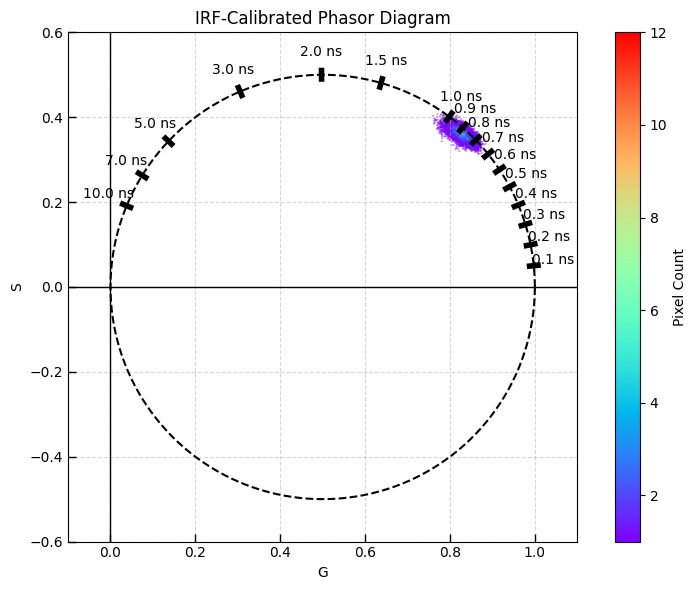

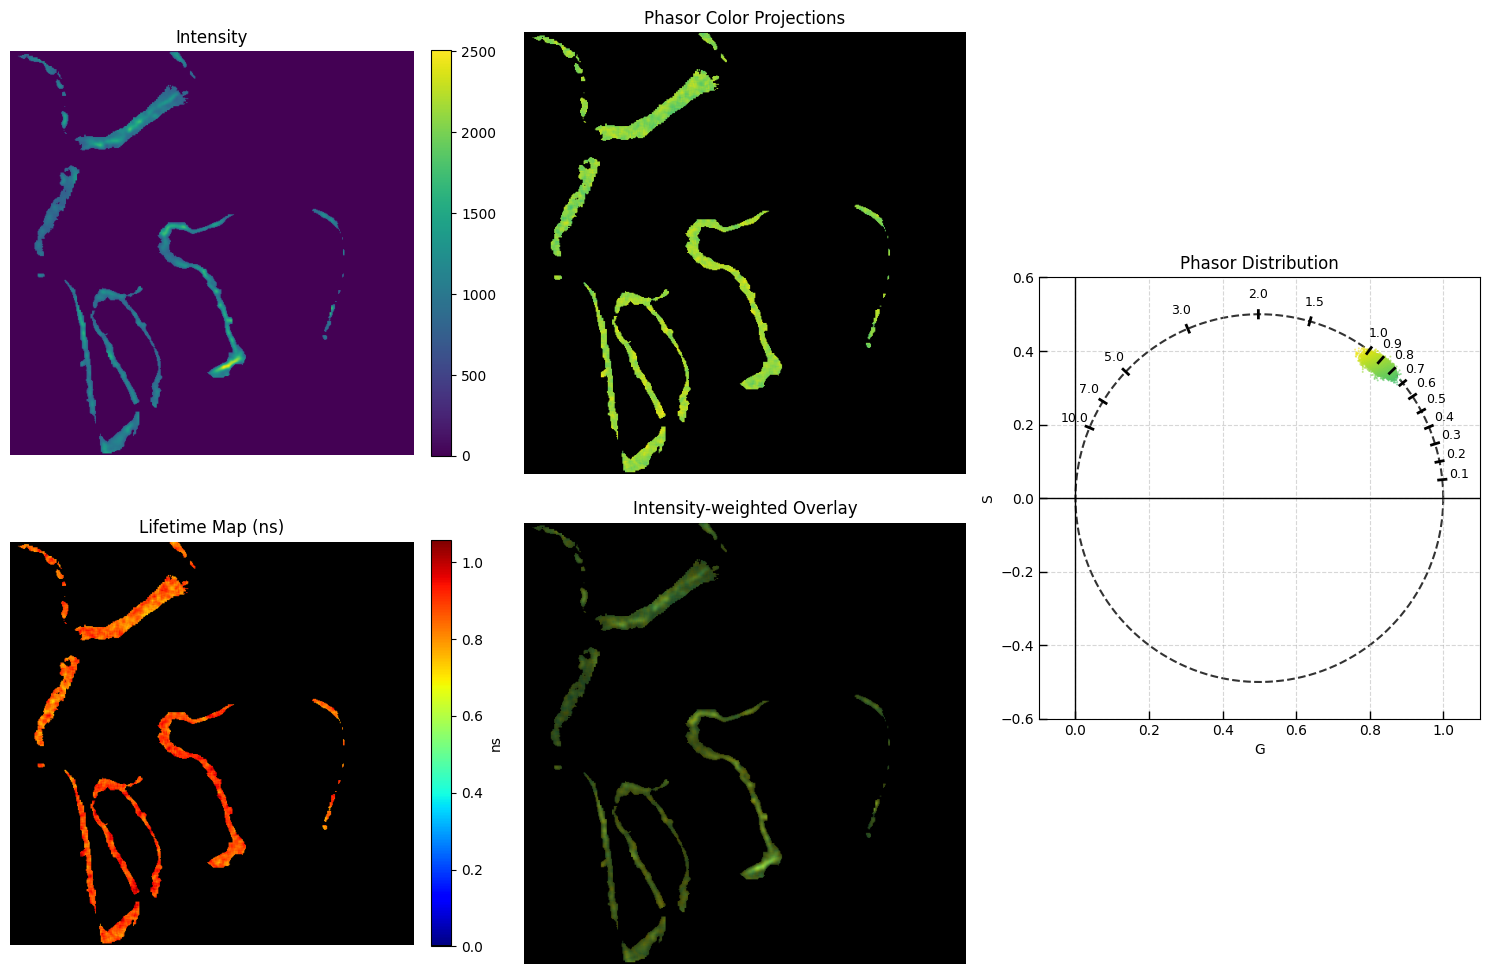

In [24]:

im1 = Phasor_binned.plot_phasor_diagram(binned_Gc[0], binned_Sc[0], mask = b_bool_mask,  hexbin_color = colorset )

im2 = Phasor_binned.plot_overlay_subplots(binned_decay, 
                                    binned_Gc[0], binned_Sc[0], 
                                    mask=b_bool_mask, 
                                    colormaps =['viridis', jet_m],
                                    hexbin_color= colorset, 
                                    figsize=(15, 10))
save_this = False
if save_this:
    saver.save_plot(name='Phasor_Plot', fig=im1, close=False)
    saver.save_plot(name='Phasor_subplots', fig=im2, close=False)


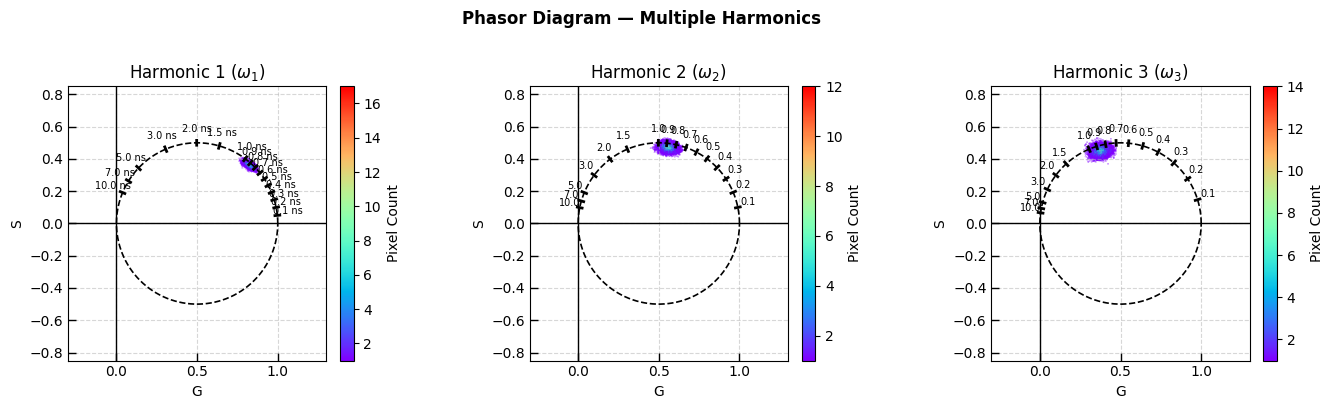

In [25]:
im3 = Phasor_binned.plot_phasor_harmonics(binned_Gc, binned_Sc, 
                                     harmonics=(1, 2, 3),
                                    mask = b_bool_mask,  
                                    hexbin_color = colorset, 
                                    figsize=(14,4))
if save_this:
    saver.save_plot(name='phasor_harmonics_Plot', fig=im3, close=False)

##### Phasor Color Projection Maps

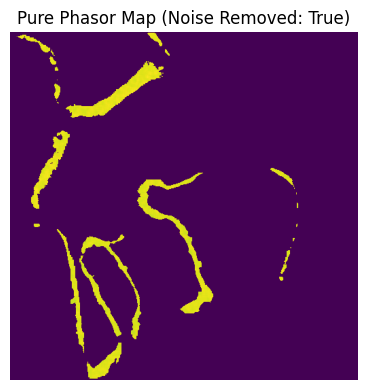

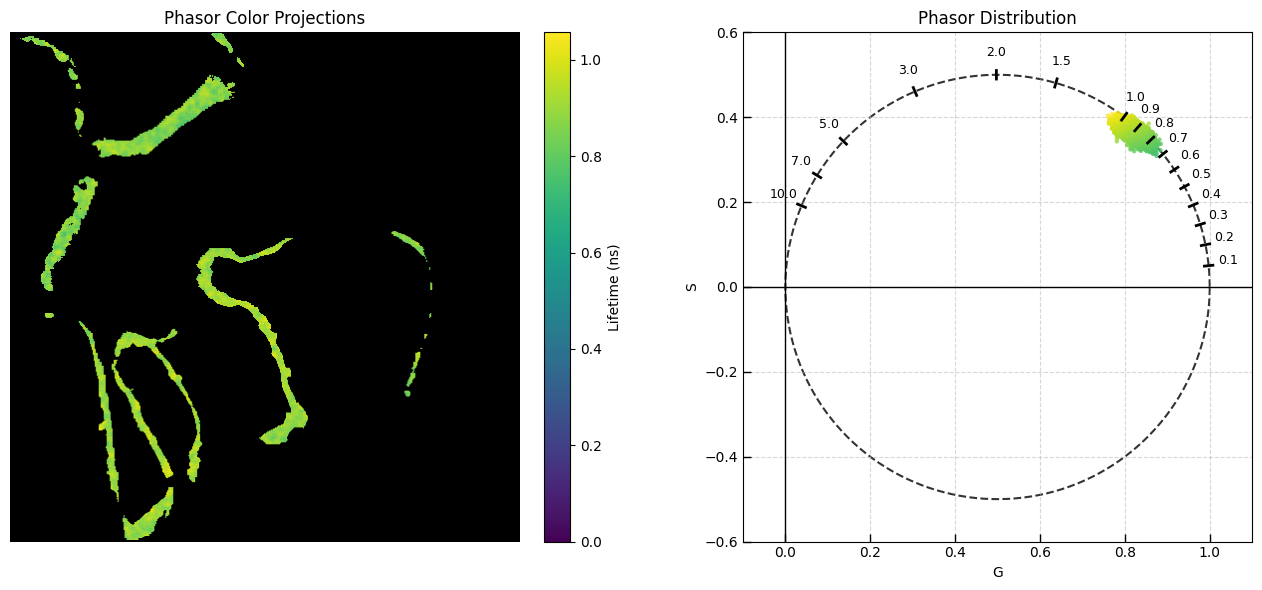

In [26]:
# Pure phasor map — each pixel colored by its phasor phase angle (encodes apparent lifetime)
im4 = Phasor_binned.plot_pure_phasor_map(binned_Gc[0], binned_Sc[0], binned_decay,
                                          noise_removed=True, colormap='viridis')
save_this = False
if save_this:
    saver.save_plot(name='phasor_pure_map', fig=im4, close=False)
plt.show()

# Traceable analysis — radial-color spatial map paired with annotated phasor diagram
im5 = Phasor_binned.plot_traceable_analysis(binned_Gc[0], binned_Sc[0], binned_decay,
                                             mask=b_bool_mask, colormap='viridis')
if save_this:
    saver.save_plot(name='phasor_traceable', fig=im5, close=False)
plt.show()

#### [Optional] Check the fitting using prior knowlege of lifetime (Phasor FRET Fraction estimation)

Reconstructed decay shape: (512, 512, 256)


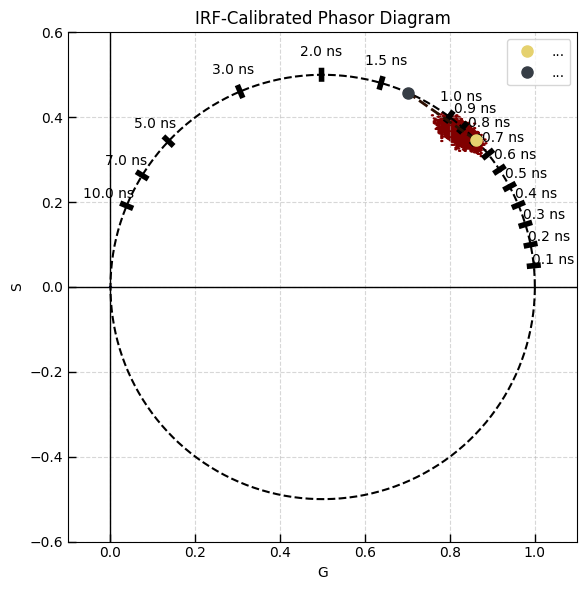

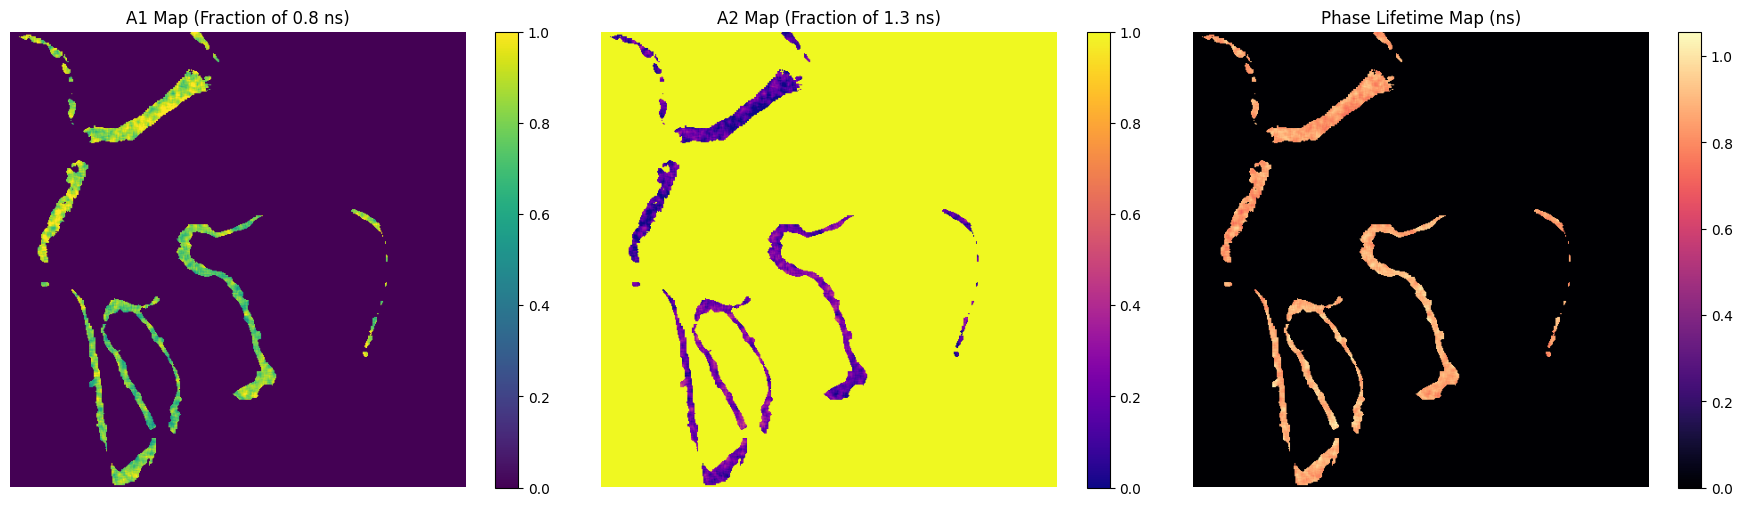

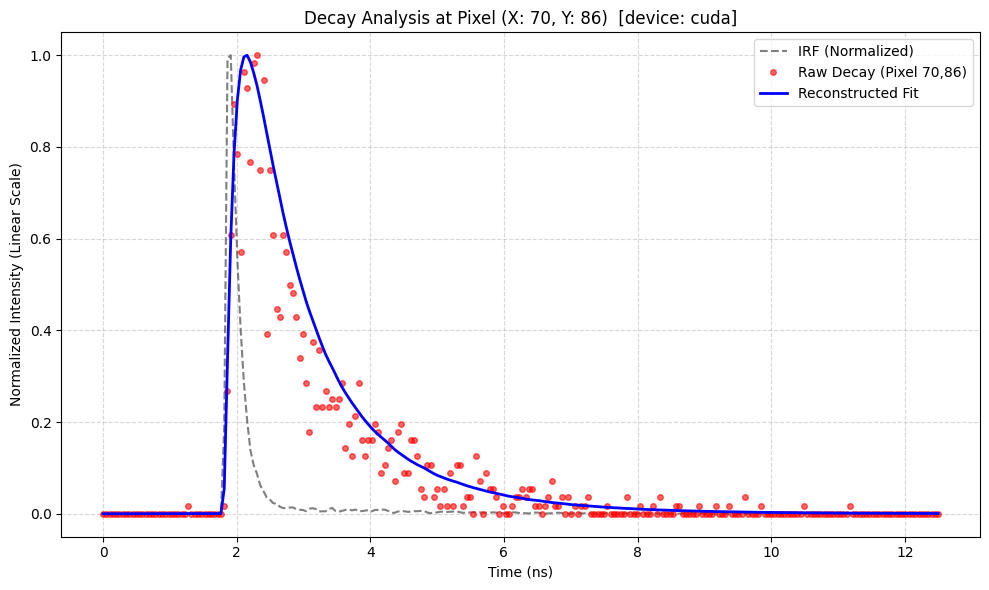

In [25]:
## >>>>>>>>>> Compute Phasor Fractions from the prior lifetime information
# user provided input 'tau1_ns', 'tau2_ns' and pixel (x,y)
x,y = random_true_pixel(b_bool_mask)
fitting_type = ['mono-exponential', 'bi-exponential'][1]

if fitting_type == 'mono-exponential':
    # user provided input 'tau_ns' and pixel (x,y)
    tau_ns = 0.9
    Phasor_binned.plot_pixel_fit_single_exp(binned_irf, binned_decay, binned_tau_map_ns, y, x, log_scale=False)
else:
    tau1_ns, tau2_ns = 0.8, 1.3
    A1, A2 = Phasor_binned.compute_fractions(binned_Gc[0], binned_Sc[0], tau1_ns, tau2_ns)
    reconstructed_decay = Phasor_binned.analyze_biexponential_and_reconstruct(
        binned_Gc[0], binned_Sc[0], binned_irf, tau1_ns=tau1_ns, tau2_ns=tau2_ns, plot=True
    )
    print(f"Reconstructed decay shape: {reconstructed_decay.shape}")
    # Checking if lifetime values selected makes sense
    Phasor_binned.plot_pixel_fit(binned_irf, binned_decay, reconstructed_decay, y, x, log_scale=False)

#### Parameter estimation >>>> Laguerre Deconvolution Method

In [27]:
from pyfli import LaguerreFLI
Lag_model = LaguerreFLI(n_components=2, 
                        n_laguerre=5, 
                        # alpha=0.85, 
                        dt=gate_delay,
                        auto_alpha=True, 
                        nonneg=True,)
        
Lag_results = Lag_model.fit(binned_decay, binned_irf).get_parameters()

In [ ]:
save_this = False
if save_this:
    saver.save_npy("Laguerre Results", Lag_results)
    saver.log('The Laguerre Results saved')


Array saved: >> Laguerre Results.npy | Type: Dictionary
The Laguerre Results saved


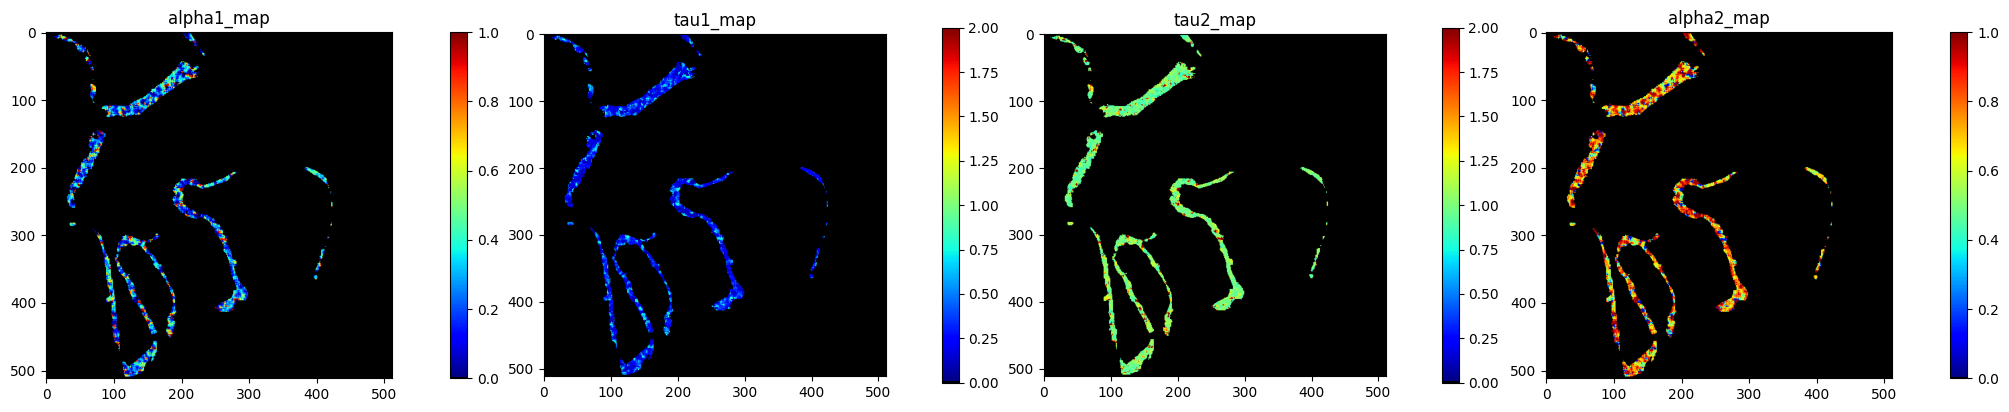

In [28]:
res = Lag_results['results']['maps']
data_list = [res['alpha1_map'], res['tau1_map'], res['tau2_map'], res['alpha2_map']]
data_names = ['alpha1_map', 'tau1_map', 'tau2_map', 'alpha2_map']
cmaps = [jet_m, jet_m, jet_m, jet_m]
v_ranges = [(0,1),(0,2),(0, 2),(0,1)]
# v_ranges = None
px = None
if px is None:
    cols = len(data_list)
else:
    cols = len(data_list)+1


save_this = False
if save_this:
    DataViewer(save_path=saver.save_dir, fig_name='Laguerre_output').display_data(data_list, structure= (1, cols), coord=px, data_names=data_names, 
                     cmaps=cmaps, v_ranges=v_ranges, figsize=None, normalize=False, yscale = 'linear')
else:
    DataViewer().display_data(data_list, structure= (1, cols), coord=px, data_names=data_names, 
                     cmaps=cmaps, v_ranges=v_ranges, figsize=None, normalize=False, yscale = 'linear')

#### Parameter estimation >>>> Analytical Methods (NLSF and MLE)

##### Single-pixel diagnostic benchmark (FittingComparator)


FLI DIAGNOSTIC BENCHMARK | Model: BI-EXPONENTIAL

╒═══════════════╤════════╤════════╤══════════╤════════╤════════╤═════════════╤═════════════════════════════════════════╕
│ Method        │ Type   │ Conv   │ Time     │     R2 │   Chi2 │   Red. Chi2 │ Parameters                              │
╞═══════════════╪════════╪════════╪══════════╪════════╪════════╪═════════════╪═════════════════════════════════════════╡
│ LEAST_SQUARES │ NLSF   │ YES    │ 19.04 ms │ 0.9219 │ 134.43 │       0.536 │ A:0.0, α:0.01, τ1:0.88, τ2:0.88, B:0.0  │
├───────────────┼────────┼────────┼──────────┼────────┼────────┼─────────────┼─────────────────────────────────────────┤
│ TRUST_REGION  │ NLSF   │ YES    │ 12.05 ms │ 0.9319 │ 160.85 │       0.641 │ A:0.0, α:0.50, τ1:1.00, τ2:1.00, B:0.0  │
├───────────────┼────────┼────────┼──────────┼────────┼────────┼─────────────┼─────────────────────────────────────────┤
│ UNCONSTRAINED │ NLSF   │ YES    │ 4.14 ms  │ 0.9321 │ 165.26 │       0.658 │ A:0.0, α:0.03, τ1:0.37,

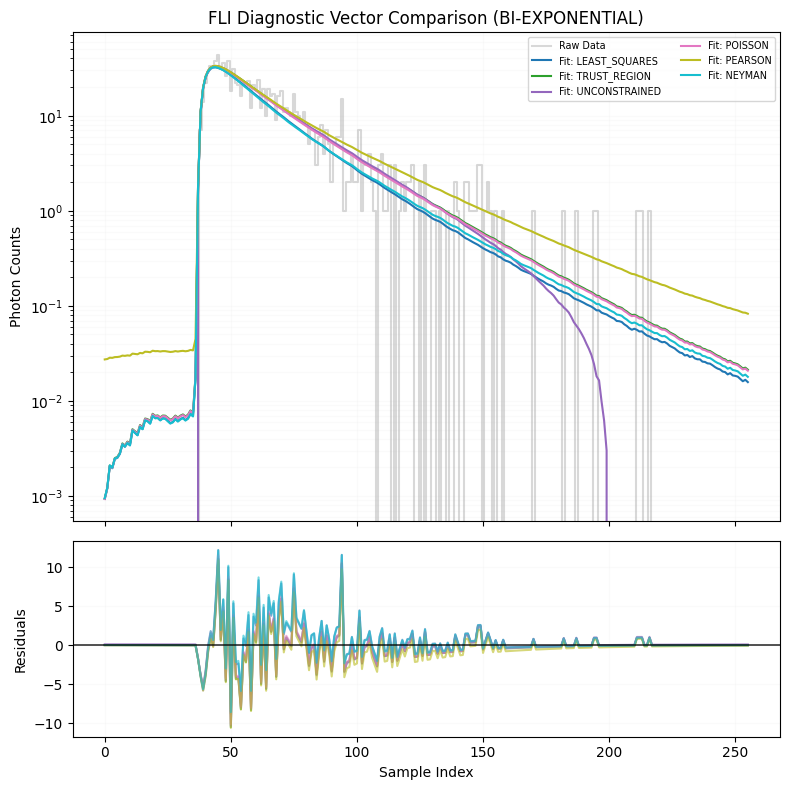

In [29]:
from pyfli import FittingComparator
# Benchmarks every fitting method on one representative pixel before running the full image.
# Prints a comparison table (R², chi², convergence, timing) and overlays all fits.
_MODEL_TYPE = ['mono-exponential', 'bi-exponential'][1]   # keep in sync with fitting loop below
_p0     = [1.0, 0.5, 0.5, 1.1, 0]
_bounds = [(0, np.inf), (0, 1), (0, 2), (0, 2), (0, np.inf)]

xd, yd = random_true_pixel(b_bool_mask)
pixel_decay = binned_decay[xd, yd, :]
pixel_irf   = binned_irf[xd, yd, :]

comparator = FittingComparator(freq, BaseFLIFitter, MLEFLIFitter)
_ = comparator.run_all(
    y_data     = pixel_decay,
    irf_data   = pixel_irf,
    model_type = _MODEL_TYPE,
    p0         = _p0,
    bounds     = _bounds,
    yscale     = 'log',
    plot       = True
)

In [ ]:
from pyfli import GlobalFLIFitter, FittingComparator
from pyfli import Fli_CPUProcessor, Fli_GPUProcessor
from pyfli import Msg_display

import itertools
import numpy as np

save_this = True
run_mode = ['single', 'all'][0]  # 0 = one config, 1 = all combinations

# --- Manual selection (only used when run_mode == 'single') ---
USE_GPU = False   # True = GPU  |  False = CPU
USE_MLE = False   # True = MLE  |  False = NLSF

# Build run list
if run_mode == 'single':
    run_combinations = [(USE_GPU, USE_MLE)]
else:
    run_combinations = list(itertools.product([False, True], [False, True]))

MODEL_TYPE = ['mono-exponential', 'bi-exponential'][1]
DATA_MODE = ['macroscopy_', 'mesoscopy_', 'microscopy_', 'simulated'][-1]
EXP_NAME = 'Nanobody'
use_initial_guess = True
use_bounds = True
full_data_name = f"{DATA_MODE}{EXP_NAME}" if EXP_NAME else DATA_MODE

for USE_GPU, USE_MLE in run_combinations:
    processing_device = Fli_GPUProcessor if USE_GPU else Fli_CPUProcessor
    fitter_class = MLEFLIFitter if USE_MLE else BaseFLIFitter
    processor_name = 'GPU' if USE_GPU else 'CPU'
    fitter_name = 'MLE' if USE_MLE else 'NLSF'
    estimator = 'poisson' if USE_MLE else 'least_squares'

    # Initial Guess & parameter bounds 
    if use_initial_guess:    
        p0 = [1.0, 1.0, 0] if MODEL_TYPE == 'mono-exponential' else [1.0, 0.5, 0.5, 1.1, 0]
    else:
        p0 = None

    if use_bounds:
        bounds = [(0, np.inf), (0, 2), (0, np.inf)] if MODEL_TYPE == 'mono-exponential' else [(0, np.inf), (0, 1), (0, 2), (0, 2), (0, np.inf)]
    else:
        bounds = None

    if save_this:    
        Msg_display(saver=saver).fit_session(
            model_type=MODEL_TYPE, 
            processor_name=processor_name, 
            fitter_name=fitter_name, 
            estimator=estimator, 
            data_name=full_data_name,
            use_initial_guess=use_initial_guess,
            p0=p0,
            use_bounds=use_bounds,
            bounds=bounds
        )
    else:
        Msg_display().fit_session(
            model_type=MODEL_TYPE, 
            processor_name=processor_name, 
            fitter_name=fitter_name, 
            estimator=estimator, 
            data_name=full_data_name,
            use_initial_guess=use_initial_guess,
            p0=p0,
            use_bounds=use_bounds,
            bounds=bounds
        )

    print(f"\n>>> Running Session: {processor_name} | {fitter_name} | {estimator}")
    
    process_loader = processing_device(freq, fitter_class)
    fitter = BinnedFliFitter(process_loader, bin_radius=bin_r)
    
    results = fitter.fit(
        b_img = binned_decay,
        b_irf = binned_irf, 
        estimator = estimator, 
        model_type = MODEL_TYPE,
        n_jobs= 4,   
        data_name = full_data_name
    )
    res_save_name = f'{processor_name}_{fitter_name}_{estimator}'
    saver.save_npy(res_save_name, results)
    saver.log(f'The computational result {res_save_name} saved')
    saver.log('-'*40)
    if free_memory:
        del results
    
    print(f"Finished combination: GPU={USE_GPU}, MLE={USE_MLE}")
    print("-" * 30)

In [ ]:
binned_decay = np.load(os.path.join(saver.save_dir, 'clean_decay.npy'), allow_pickle=True)
binned_irf = np.load(os.path.join(saver.save_dir, 'clean_irf.npy'), allow_pickle=True)
b_bool_mask = np.load(os.path.join(saver.save_dir, 'final_mask.npy'), allow_pickle=True)
print(binned_decay.shape)
print(binned_irf.shape)
print(b_bool_mask.shape)

(512, 512, 256)
(512, 512, 256)
(512, 512)


#### [Optional] GlobalFLIFitter — cluster-seeded pixel fitting

Requires a **labeled integer mask** (values 1, 2, 3 … per region).  
Below, the entire ROI is treated as one cluster (label = 1) for demonstration.  
For multi-region analysis, supply a mask from `ROIMaker` or any segmentation tool.

In [ ]:
run_global_fitter = [False, True][0]   # set to 1 to run

if run_global_fitter:
    _MODEL_TYPE_G = ['mono-exponential', 'bi-exponential'][1]
    _ESTIMATOR_G  = ['least_squares', 'poisson'][0]
    _p0_g     = [1.0, 0.5, 0.5, 1.1, 0]
    _bounds_g = [(0, np.inf), (0, 1), (0, 2), (0, 2), (0, np.inf)]

    # Build labeled cluster mask: 0 = background, 1 = full ROI
    # Replace with a multi-label mask for true per-region seeding
    cluster_mask = b_bool_mask.astype(np.int32)

    cpu_proc = Fli_CPUProcessor(freq, BaseFLIFitter)

    gfitter = GlobalFLIFitter(
        freq              = freq,
        base_fitter_class = BaseFLIFitter,
        mle_fitter_class  = MLEFLIFitter,
        processor_instance= cpu_proc
    )

    # Step 1 — extract per-cluster data
    gfitter.make_clusters(binned_decay, binned_irf, cluster_mask, min_cluster_size=10)

    # Step 2 — super-pixel fit + pixel-wise fitting seeded from super-pixel params
    cluster_results, sp_data, sp_params = gfitter.process_clusters(
        image_cube       = binned_decay,
        irf_cube         = binned_irf,
        mask             = b_bool_mask,
        model_type       = _MODEL_TYPE_G,
        estimator        = _ESTIMATOR_G,
        p0               = _p0_g,
        bounds           = _bounds_g,
        global_inference = True,
        n_jobs           = 4,
        data_name        = 'Global_ROI'
    )

    # Step 3 — stitch clusters back into full-image maps
    H, W, T = binned_decay.shape
    global_stitched = gfitter.stitch_results(cluster_results, H, W, T, model_type=_MODEL_TYPE_G)

    global_maps = global_stitched['results']['maps']
    data_list_g  = [global_maps['alpha1_map'], global_maps['tau1_map'], global_maps['tau2_map']]
    data_names_g = ['alpha1_global', 'tau1_global', 'tau2_global']
    DataViewer().display_data(data_list_g, structure=(1, 3), coord=None,
                              data_names=data_names_g, cmaps=[jet_m]*3,
                              v_ranges=[(0,1),(0,2),(0,2)], figsize=None,
                              normalize=False, yscale='linear')

    save_this = True
    if save_this:
        saver.save_npy('global_fitter_results', global_stitched)
        saver.log('GlobalFLIFitter stitched results saved')

#### Processing F-BI output

In [9]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import bayesflow as bf

from bayesflow.networks import SummaryNetwork
import keras
from keras import layers

I0000 00:00:1779291135.006242 1295781 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779291136.175010 1295781 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779291139.563798 1295781 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
INFO:bayesflow:Using backend 'tensorflow'
I0000 00:00:1779291140.357086 1295781 gpu_device.cc:2043] Created device /job:loc

In [10]:
## Loading the DL model
@bf.utils.serialization.serializable("custom")
class MultiScaleConv(layers.Layer):
    def __init__(self, filters_per_branch=32, kernel_sizes=(1, 3, 9, 27), **kwargs):
        super().__init__(**kwargs)
        self.branches = [
            layers.Conv1D(
                filters=filters_per_branch,
                kernel_size=k,
                padding="same",
                use_bias=False,
            )
            for k in kernel_sizes
        ]
        self.norm = layers.LayerNormalization(axis=-1)
        self.act = layers.Activation("swish")

    def call(self, inputs, training=False):
        x = inputs
        outs = [branch(x) for branch in self.branches]
        x = layers.Concatenate(axis=-1)(outs)
        x = self.norm(x)
        return self.act(x)

@bf.utils.serialization.serializable("custom")
class ResidualBlock(layers.Layer):
    def __init__(self, filters, dilation_rate=1, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = layers.Conv1D(
            filters,
            kernel_size=3,
            dilation_rate=dilation_rate,
            padding="same",
            activation="swish",
        )
        self.conv2 = layers.Conv1D(
            filters,
            kernel_size=3,
            dilation_rate=dilation_rate,
            padding="same",
        )
        self.norm = layers.LayerNormalization(axis=-1)
        self.act = layers.Activation("swish")

    def call(self, x):
        y = self.conv1(x)
        y = self.conv2(y)
        y = self.norm(y)
        return self.act(x + y)

@bf.utils.serialization.serializable("custom")
class MultiScaleRNNSummaryNet(SummaryNetwork):
    def __init__(
        self,
        rnn_units_list=(64,),
        filters_per_branch=16,
        ms_kernel_sizes=(1, 3, 9, 27),
        num_res_blocks=2,
        embedding_dim=256,
        **kwargs
    ):
        super().__init__(**kwargs)
        # Stacked bidirectional GRUs
        self.gru_layers = []
        for units in rnn_units_list:
            self.gru_layers.append(
                layers.GRU(units, return_sequences=True)
                # layers.Bidirectional(layers.GRU(units, return_sequences=True))
            )
        # Multi-scale CNN
        self.ms_conv = MultiScaleConv(filters_per_branch, ms_kernel_sizes)
        total_filters = filters_per_branch * len(ms_kernel_sizes)
        # Residual blocks
        self.res_blocks = [
            ResidualBlock(filters=total_filters, dilation_rate=2**i)
            for i in range(num_res_blocks)
        ]
        # Global pooling + dense embedding
        self.pool = layers.GlobalAveragePooling1D()
        self.fc_out = layers.Dense(embedding_dim, activation="swish")

    def call(self, inputs, training=False):
        x = inputs
        # GRU processing
        for gru in self.gru_layers:
            x = gru(x)
        # Concatenate GRU output with original input (skip)
        x = layers.Concatenate(axis=-1)([inputs, x])
        # Multi-scale CNN
        x = self.ms_conv(x)
        # Residual blocks
        for blk in self.res_blocks:
            x = blk(x)
        # Global pooling + embedding
        x = self.pool(x)
        return self.fc_out(x)

In [ ]:
# Loading the model weight
saved_model_path = '../data/hbi_saved_model/microscopy/all_config.keras' 
if os.path.exists(saved_model_path):
    loaded_model = keras.saving.load_model(saved_model_path)

I0000 00:00:1779291154.786386 1296604 cuda_dnn.cc:461] Loaded cuDNN version 92101
/home/pandev2/miniconda3/envs/myfli_env/lib/python3.11/site-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


In [ ]:
# Model output computation
IMG_SIZE1 = binned_decay.shape[0]
IMG_SIZE2 = binned_decay.shape[1]
PATCH_SIZE1 = 128
PATCH_SIZE2 = 128
NUM_PATCHES_SIDE1 = IMG_SIZE1 // PATCH_SIZE1
NUM_PATCHES_SIDE2 = IMG_SIZE2 // PATCH_SIZE2
output_maps = {
    'tau1': np.zeros((IMG_SIZE1, IMG_SIZE2)),
    'tau2': np.zeros((IMG_SIZE1, IMG_SIZE2)),
    'f':    np.zeros((IMG_SIZE1, IMG_SIZE2))
}

output_uncertainties = {
    'tau1': np.zeros((IMG_SIZE1, IMG_SIZE2)),
    'tau2': np.zeros((IMG_SIZE1, IMG_SIZE2)),
    'f':    np.zeros((IMG_SIZE1, IMG_SIZE2))
}

k = 0
for i in range(NUM_PATCHES_SIDE1):
    for j in range(NUM_PATCHES_SIDE2):
        r_start, r_end = i * PATCH_SIZE1, (i + 1) * PATCH_SIZE1
        c_start, c_end = j * PATCH_SIZE2, (j + 1) * PATCH_SIZE2 

        patch_decay = binned_decay[r_start:r_end, c_start:c_end, :].reshape(-1, binned_decay.shape[-1])
        patch_irf   = binned_irf[r_start:r_end, c_start:c_end, :].reshape(-1, binned_irf.shape[-1]) 
        
        patch_conditions = {
            'decay': patch_decay,
            'irf': patch_irf
        }
        if free_memory:
            del patch_decay, patch_irf
        k += 1
        print(f'processing patch: {k}')
        out = loaded_model.sample(conditions=patch_conditions, num_samples=100, batch_size=1024)
        if free_memory:
            del patch_conditions

        for key in output_maps.keys():
            val = np.median(out[key].squeeze(), axis=1)
            patch_values = val.reshape(PATCH_SIZE1, PATCH_SIZE2)
            output_maps[key][r_start:r_end, c_start:c_end] = patch_values

        for key in output_uncertainties.keys():
            val = median_abs_deviation(out[key].squeeze(), axis=1)
            patch_values = val.reshape(PATCH_SIZE1, PATCH_SIZE2)
            output_uncertainties[key][r_start:r_end, c_start:c_end] = patch_values
        if free_memory:
            del out

print("Restitching done")
print(f"Final Map Shape: {output_maps['tau1'].shape}")

In [19]:
save_this = True
if save_this:
    saver.save_npy("F-BI Output", output_maps)
    saver.log('The F-BI Output saved')
    saver.save_npy("F-BI output_uncertainties", output_uncertainties)
    saver.log('The F-BI output_uncertainties saved')


Array saved: >> F-BI Output.npy | Type: Dictionary
The F-BI Output saved
Array saved: >> F-BI output_uncertainties.npy | Type: Dictionary
The F-BI output_uncertainties saved


In [ ]:
import numpy as np
from scipy.signal import fftconvolve

bins = binned_irf.shape[-1]
params = 3 
eps = 1e-8 
tau1 = np.clip(output_maps['tau1'][..., np.newaxis], eps, None)
tau2 = np.clip(output_maps['tau2'][..., np.newaxis], eps, None)
f = output_maps['f'][..., np.newaxis]
t = np.linspace(0, 1000/freq[1], bins)

sdf = f * np.exp(-t / tau1) + (1 - f) * np.exp(-t / tau2)
if free_memory:
    del tau1, tau2, f, t

convolved_fit = fftconvolve(sdf, binned_irf, mode='full', axes=-1)[..., :bins]

calculated_photon_count = np.sum(binned_decay, axis=-1)
fit_sum = np.sum(convolved_fit, axis=-1, keepdims=True)

fit_pdf = np.zeros_like(convolved_fit)
np.divide(convolved_fit, fit_sum, out=fit_pdf, where=fit_sum > eps)
if free_memory:
    del convolved_fit, fit_sum

scaled_fit = calculated_photon_count[..., np.newaxis] * fit_pdf
if free_memory:
    del fit_pdf

variance = scaled_fit.copy()
variance[variance <= 0] = 1.0  # Statistical variance cannot be zero for Chi-Sq
dof = bins - params - 1

residuals = binned_decay - scaled_fit
sq_err = (residuals**2) / variance
if free_memory:
    del variance

chi_sq_map = np.sum(sq_err, axis=-1) / dof
if free_memory:
    del sq_err

output_maps['sdf'] = sdf
output_maps['fit'] = scaled_fit
output_maps['residuals'] = residuals
output_maps['chi_sq'] = chi_sq_map
output_maps['photon_count'] = calculated_photon_count

mask = calculated_photon_count > 0
mean_chi_sq = np.mean(chi_sq_map[mask]) if np.any(mask) else np.nan

print(f"Mean Chi-Squared (Active Pixels): {mean_chi_sq:.4f}")

###### Plotting F-BI parameter Uncertainity

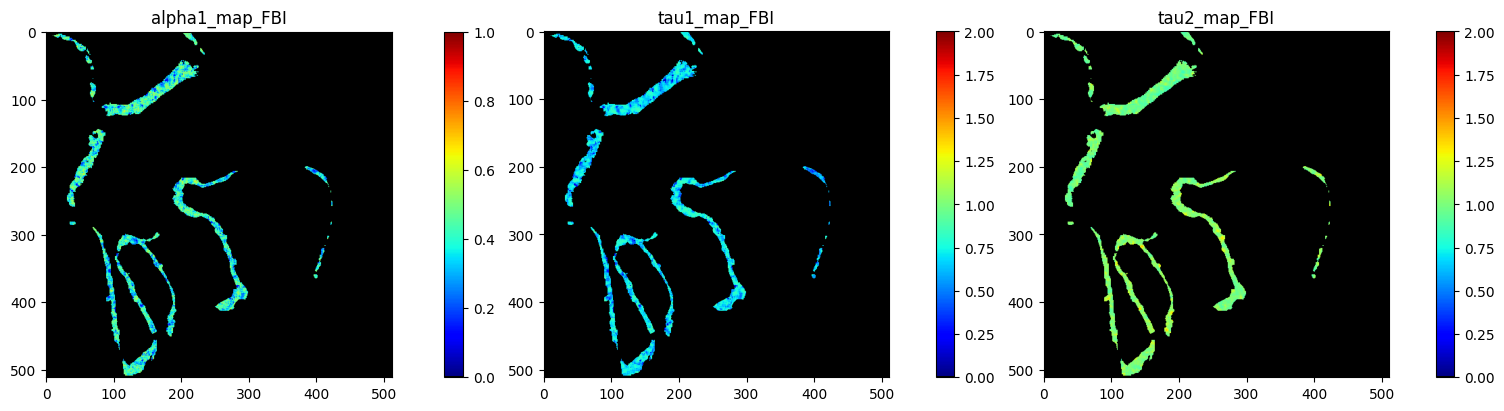

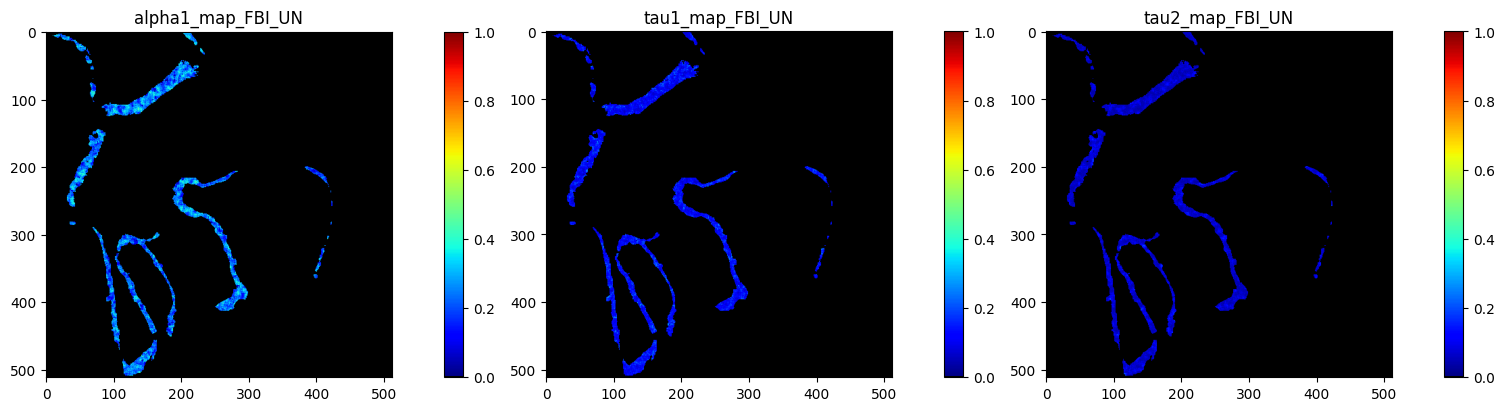

In [18]:
data_list = [output_uncertainties['f'], output_uncertainties['tau1'], output_uncertainties['tau2']]*b_bool_mask
data_list1 = [output_maps['f'], output_maps['tau1'], output_maps['tau2']]*b_bool_mask
data_names = ['alpha1_map_FBI_UN','tau1_map_FBI_UN', 'tau2_map_FBI_UN']
data_names1 = ['alpha1_map_FBI','tau1_map_FBI', 'tau2_map_FBI']
cmaps = [jet_m, jet_m, jet_m]
v_ranges1 = [(0,1),(0,2),(0, 2)]
v_ranges = [(0,1),(0,1),(0, 1)]
px = None
if px is None:
    cols = len(data_list)
else:
    cols = len(data_list)+1
DataViewer().display_data(data_list1, structure= (1, cols), coord=px, data_names=data_names1, 
                     cmaps=cmaps, v_ranges=v_ranges1, figsize=None, normalize=False, yscale = 'linear')
DataViewer().display_data(data_list, structure= (1, cols), coord=px, data_names=data_names, 
                     cmaps=cmaps, v_ranges=v_ranges, figsize=None, normalize=False, yscale = 'linear')

In [ ]:
res_cpu_nlsf = np.load(os.path.join(saver.save_dir, 'CPU_NLSF_least_squares.npy'), allow_pickle=True).item()
res_gpu_nlsf = np.load(os.path.join(saver.save_dir, 'GPU_NLSF_least_squares.npy'), allow_pickle=True).item()
res_cpu_mle = np.load(os.path.join(saver.save_dir, 'CPU_MLE_poisson.npy'), allow_pickle=True).item()
res_gpu_mle = np.load(os.path.join(saver.save_dir, 'GPU_MLE_poisson.npy'), allow_pickle=True).item()
# print(res_cpu_nlsf['results'].keys())
# print(res_gpu_nlsf['results'].keys())
# print(res_cpu_mle['results'].keys())
# print(res_gpu_mle['results'].keys())

dict_keys(['maps', 'error_maps', 'TR_maps'])


In [ ]:
Lag_results = np.load(os.path.join(saver.save_dir, 'Laguerre Results.npy'), allow_pickle=True).item()
output_maps = np.load(os.path.join(saver.save_dir, 'F-BI Output.npy'), allow_pickle=True).item()
data6 = {
    'alpha1_map': output_maps['f'],
    'tau1_map': output_maps['tau1'],
    'tau2_map': output_maps['tau2']
}

experiments = {
    'CPU_NLSF_least_squares.npy': '_cpu_nlsf',
    'GPU_NLSF_least_squares.npy': '_gpu_nlsf',
    'CPU_MLE_poisson.npy':        '_cpu_mle',
    'GPU_MLE_poisson.npy':        '_gpu_mle'
}

all_datasets = [Lag_results['results']['maps']]

for file_name, name_add in experiments.items():
    file_path = os.path.join(saver.save_dir, file_name)
    var  = np.load(file_path, allow_pickle=True).item()
    res_ = var['results']['maps']
    all_datasets.append(res_)

    data_list  = [res_['alpha1_map'], res_['tau1_map'], res_['tau2_map']]
    data_names = [f'alpha1_map{name_add}', f'tau1_map{name_add}', f'tau2_map{name_add}']
    save_this = True
    viewer_kwargs = {'save_path': saver.save_dir, 'fig_name': name_add} if save_this else {}
    DataViewer(**viewer_kwargs).display_data(
        data_list, structure=(1, 3), coord=None,
        data_names=data_names, cmaps=[jet_m]*3,
        v_ranges=[(0,1),(0,2),(0,2)], figsize=None, normalize=False, yscale='linear'
    )

all_datasets.append(data6)

# ─────────────────────────────────────────────────────────────────────────────
# Plotter — Data Operations Config
# ops_mode: 0 = none | 1 = shared (same ops for all sources) | 2 = per_source
# ─────────────────────────────────────────────────────────────────────────────
ops_mode = ['none', 'shared', 'per_source'][1]

# ── Shared: all six sources get the same cleaning pipeline ───────────────────
_shared_ops = {
    "mask":            b_bool_mask,   # restrict to ROI pixels only
    "remove_nan":      True,          # drop non-finite values (failed fits)
    "remove_zero":     True,          # drop exact zeros (masked / unfit pixels)
    "threshold":       (0, 2),        # keep values in [0, 2] — covers α∈[0,1] and τ∈[0,2 ns]
    "percentile_clip": (1, 99),       # clip extreme 1 % outliers from each end
    # "custom": lambda x: x,         # optional: any f(2D array) → 2D array
}

# ── Per-source: one dict per source, index-matched to all_datasets ────────────
# Use this when different estimators need different noise handling.
_per_source_ops = [
    # Laguerre — stable; standard mask + range check
    {"mask": b_bool_mask, "remove_nan": True, "remove_zero": True, "threshold": (0, 2)},
    # NLSF CPU
    {"mask": b_bool_mask, "remove_nan": True, "remove_zero": True, "threshold": (0, 2)},
    # NLSF GPU
    {"mask": b_bool_mask, "remove_nan": True, "remove_zero": True, "threshold": (0, 2)},
    # MLE CPU — Poisson fits can produce more extreme outliers; add percentile clip
    {"mask": b_bool_mask, "remove_nan": True, "remove_zero": True,
     "threshold": (0, 2), "percentile_clip": (2, 98)},
    # MLE GPU
    {"mask": b_bool_mask, "remove_nan": True, "remove_zero": True,
     "threshold": (0, 2), "percentile_clip": (2, 98)},
    # F-BI — fraction output α∈[0,1]; tau maps still [0,2]
    {"mask": b_bool_mask, "remove_nan": True, "remove_zero": True, "threshold": (0, 2)},
]

plotter_ops = {'none': None, 'shared': _shared_ops, 'per_source': _per_source_ops}[ops_mode]

# ─────────────────────────────────────────────────────────────────────────────
colors_list = [
    "#5DADE2", "#EC7063", "#58D68D", "#F4D03F", "#AF7AC5",
    "#EB984E", "#48C9B0", "#52BE80", "#AAB7B8", "#F1948A",
    "#BB8FCE", "#7FB3D5", "#76D7C4"
]
keys_to_plot = ['alpha1_map', 'tau1_map', 'tau2_map']
names = ["Laguerre Results", "NLSF_CPU", "NLSF_GPU", "MLE_CPU", "MLE_GPU", "F-BI"]

painter = Plotter(
    *all_datasets,
    values       = keys_to_plot,
    style_config = colors_list,
    source_names = names,
    operations   = plotter_ops,
)

painter.make_plot(
    title             = "Multi Data display",
    graph_type        = 'raincloud',
    point_type        = "strip",
    show_mean         = True,
    show_median       = True,
    y_range           = (-5, 5),
    show_significance = True,
    test_type         = 'paired',
    correction        = False,
)

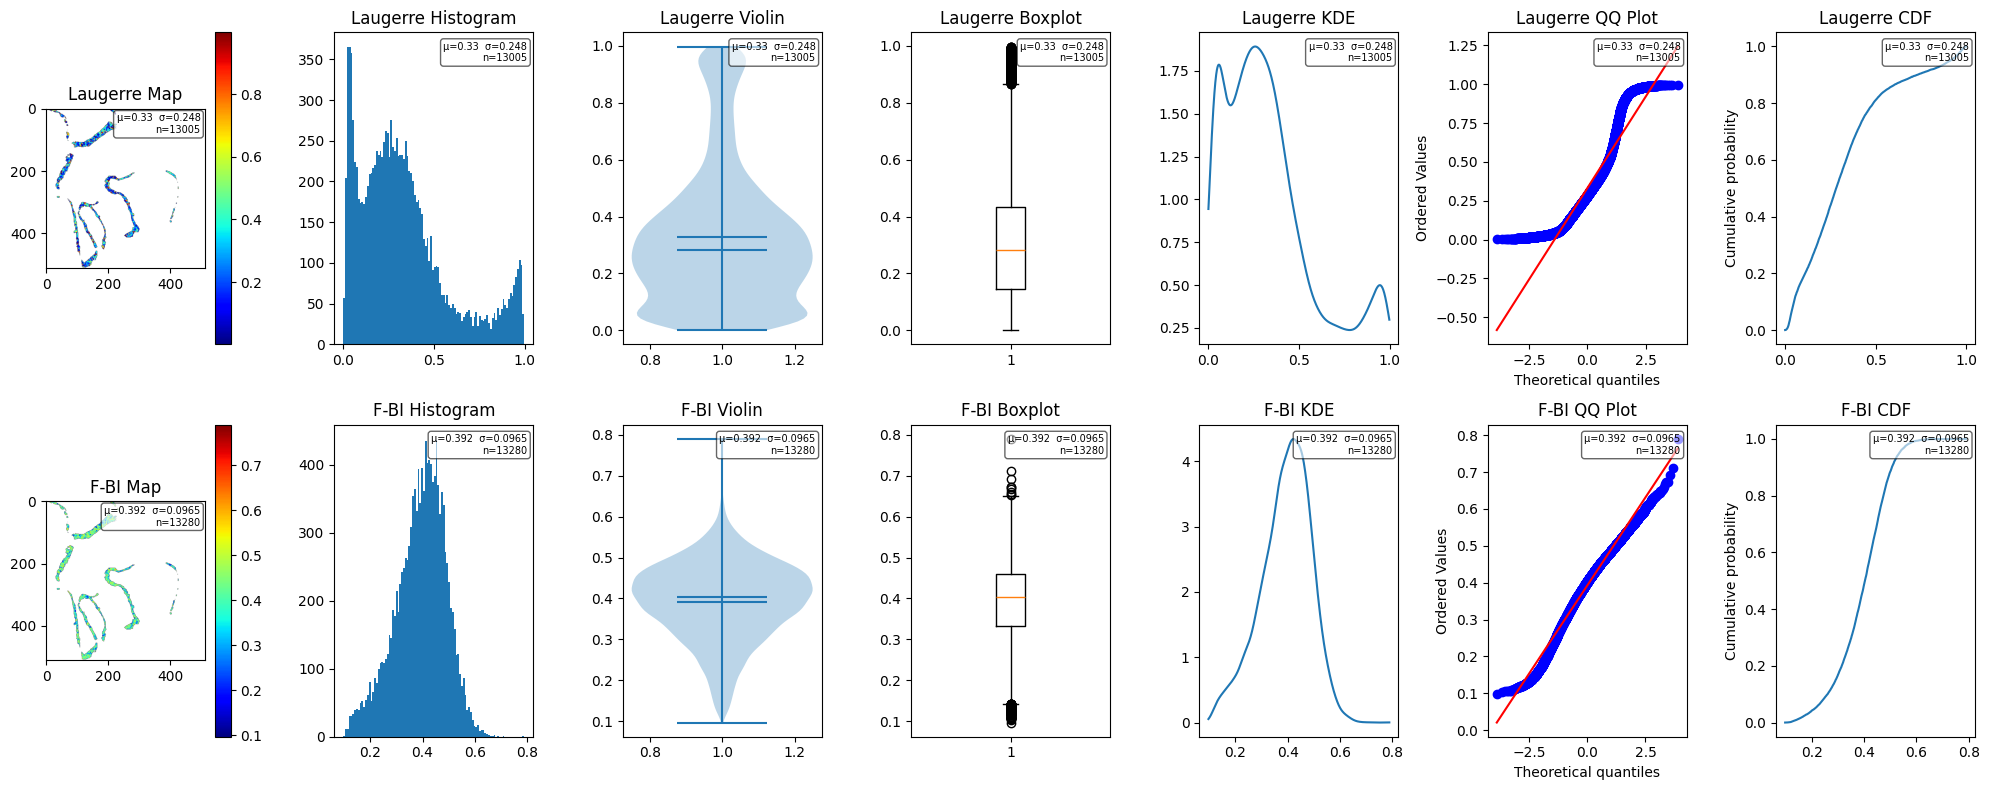

In [ ]:
from pyfli  import plot_2d_subplots
data_1 = Lag_results['results']['maps']['alpha1_map']
data_2 = data6['alpha1_map']
plot_types =["map", "histogram", "violinplot", "boxplot", "KDE", "qq", "cdF"] 
titles =["Laugerre", "F-BI"] 
operations =[{"remove_nan": True,
            "remove_zero": True,
            "threshold": (0,1),
            "mask": b_bool_mask},
        {"remove_nan": True,
         "remove_zero": True,
            "threshold": (0, 1),
            "mask": b_bool_mask}]
fig = plot_2d_subplots(data_1, data_2, 
                plot_types= plot_types,
                titles = titles,
                operations = operations,
                figsize = (20, 8), 
                cmap = 'jet')